In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
DATASET = "https://raw.githubusercontent.com/aiedu-courses/eda_and_dev_tools/main/datasets/abalone.csv"

In [ ]:
df = pd.read_csv(DATASET)

## 1. Общее исследование данных: проверить размеры таблицы, число столбцов, количество пропусков в столбцах.

## Описание данных

# Предсказать возраст абалона по его физическим измерениям.

## Признаки:

Sex — половой признак:

M (самец), F (самка), I (детёныш)

Length — наибольшая длина раковины

Diameter — диаметр, перпендикулярный длине

Height — высота с мясом внутри раковины

Whole weight — масса всего абалона

Shucked weight — масса мяса

Viscera weight — масса внутренностей (после удаления крови)

Shell weight — масса раковины после сушки


## Целевая переменная:

Rings — целочисленный признак

Возраст в годах вычисляется как: Age = Rings + 1.5

In [ ]:
df.head() # проверка загрузки данных c начала

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,NaN,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [ ]:
df.tail(10) # проверка загрузки данных с конца

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
4167,M,0.500,0.380,0.125,0.5770,0.2690,0.1265,0.1535,9
4168,F,0.515,0.400,0.125,0.6150,0.2865,0.1230,0.1765,8
4169,M,0.520,0.385,0.165,0.7910,0.3750,0.1800,0.1815,10
4170,M,0.550,0.430,0.130,0.8395,0.3155,0.1955,0.2405,10
4171,M,0.560,0.430,0.155,0.8675,0.4000,0.1720,0.2290,8
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10
4176,M,0.710,0.555,0.195,1.9485,0.9455,0.3765,0.4950,12


In [ ]:
df.shape # размеры таблицы

(4177, 9)

Данные содержат 4177 строк и 9 столбцов

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4078 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4078 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4127 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [ ]:
len(df[df.duplicated()]) # количество повторяющихся строк

0

In [ ]:
df.isnull().mean() * 100 # смотрим по каждому столбцу есть ли пропуски

,0
Sex,0.000000
Length,0.000000
Diameter,2.370122
Height,0.000000
Whole weight,2.370122
Shucked weight,0.000000
Viscera weight,0.000000
Shell weight,1.197031
Rings,0.000000


In [ ]:
df.isna().sum().sum() # общее количество пропусков

np.int64(248)

есть пропуски - 248, надо либо удалить эти строчки, либо вставить туда среднее значение по колонке

## 2. Однофакторный анализ: по каждому столбцу посмотреть его распределение. Если есть пропуски и ошибочные значения - обработать их. Посмотреть связь с целевой переменной

### Распределение по каждому столбцу

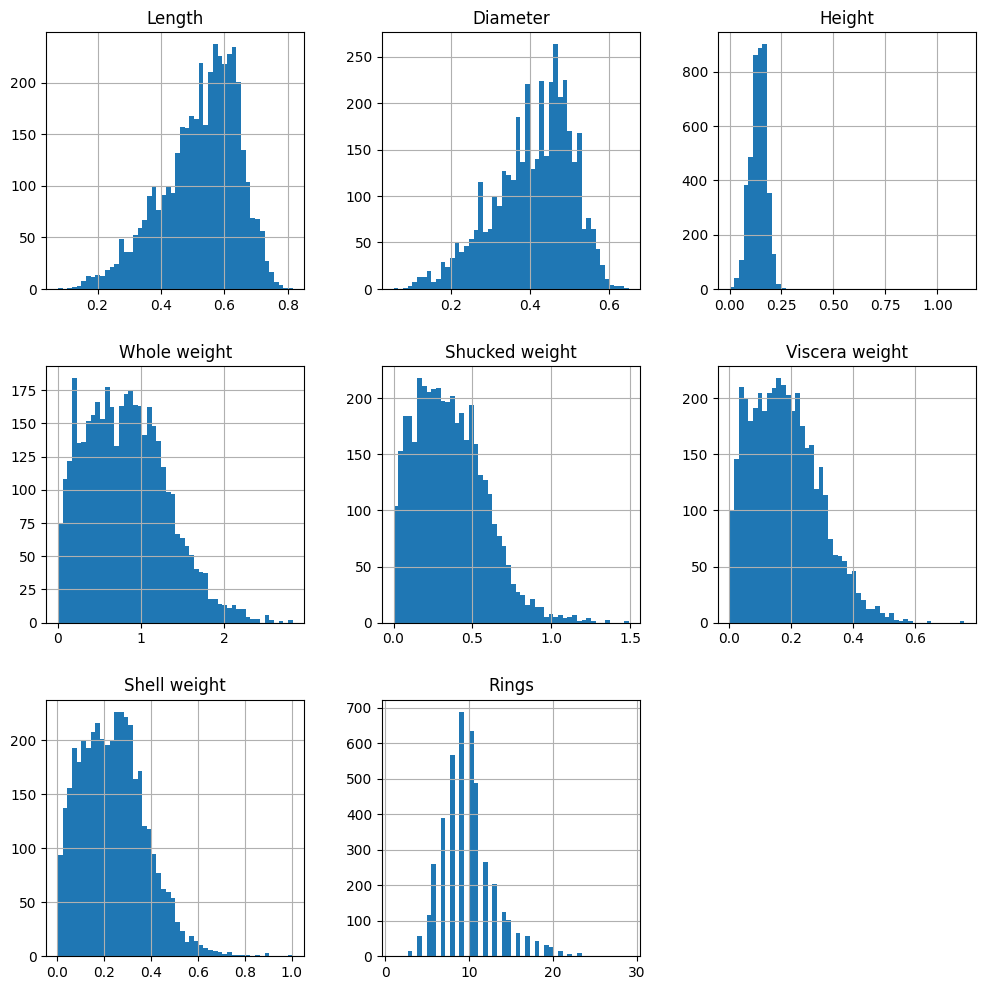

In [ ]:
df.hist(bins=50, figsize=(12, 12))
plt.show()

Параметры: Diameter, Whole weight, Shell weight имеют пропуски

Whole weight и Shell weigh не имеют выбрасов, которые могут повлиять на среднее значение

Diameter имеет несколько выбрасов, поэтому можно посмотреть наиболее популярное значение


In [ ]:
median_diameter = df['Diameter'].median()

median_weight = df['Whole weight'].median()

median_shell = df['Shell weight'].median()

print(median_diameter, median_weight, median_shell)

0.425 0.7985 0.235


In [ ]:
df['Diameter'].mode().iloc[0]

np.float64(0.45)

среднее значение и наиболее популярное похоже, поэтому будем использовать среднее значение

In [ ]:
df['Diameter'] = df['Diameter'].fillna(median_diameter)

In [ ]:
df['Whole weight'] = df['Whole weight'].fillna(median_weight)

In [ ]:
df['Shell weight'] = df['Shell weight'].fillna(median_shell)

In [ ]:
df.isnull().mean() * 100 # проверка замены

,0
Sex,0.0
Length,0.0
Diameter,0.0
Height,0.0
Whole weight,0.0
Shucked weight,0.0
Viscera weight,0.0
Shell weight,0.0
Rings,0.0


Не осталось пустых ячеек

Для просмотра связи с целевой переменной рассмотрим корреляцию

<Axes: >

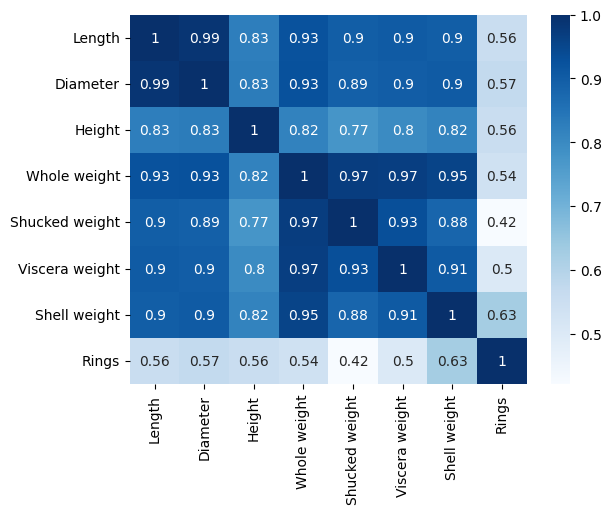

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="Blues", annot=True)

Все признаки зависят от целевой переменной, хоть rings имеет наименьшую корреляцию среди всех, но она все равно не маленькая, поэтому можно сделать вывод, что все признаки зависят друг от друга. Наименьшая корреляция с целевой переменной есть у Shucked weight, это значит, что с ростом признака целевая переменная тоже, в среднем, растёт, но связь не идеально линейная, возможно есть выбросы, надо посмотреть корреляцию Спирмена

## 3. Построить матрицу корреляций (или ее аналог для категориальных признаков): использовать корреляции, тест χ 2, ANOVA.

Корреляция Спирмена

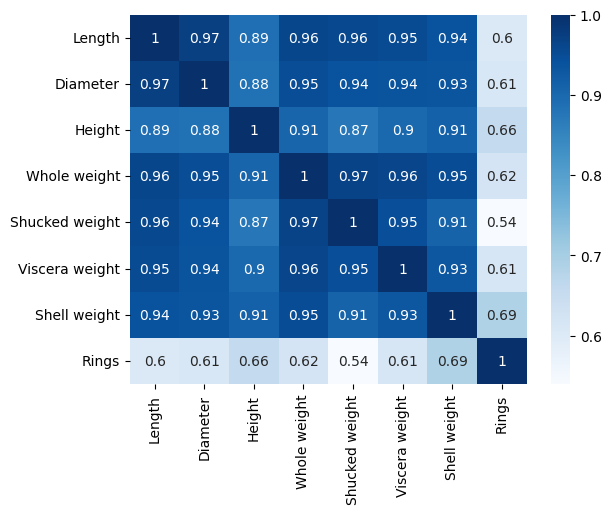

In [ ]:
corr = df.corr(method='spearman', numeric_only=True)

sns.heatmap(corr, cmap="Blues", annot=True);

В корреляции Спирмена уже значения выше, значит есть выбросы, но значения достаточно высокие, все равно они зависят


Корреляция Кендaлла

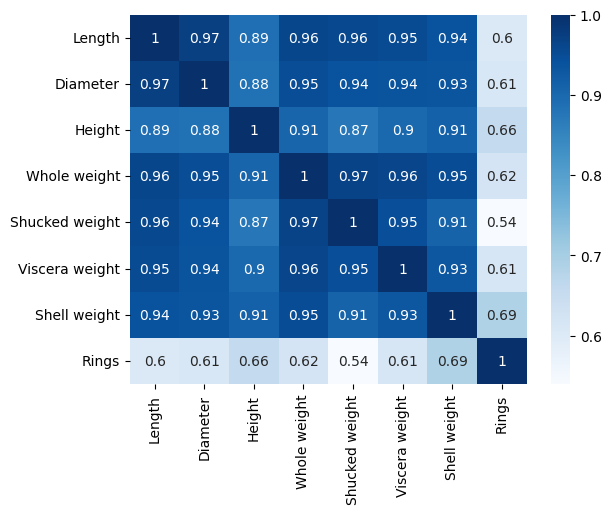

In [117]:
df.corr(method='kendall', numeric_only=True)
sns.heatmap(corr, cmap="Blues", annot=True);

Результаты корреляции Кендалла такие же как корреляция Спирмена, что указывает на монотонную зависимость. Это подтверждает, что выявленные связи не являются следствием выбросов.

Для подсчета категориальных переменных используем V - меру Крамера (тест X 2), такая колонка лишь одна, поэтому корреляция только 1

In [ ]:
!pip install association-metrics

  Preparing metadata (setup.py) ... done
  Created wheel for association-metrics: filename=association_metrics-0.0.1-py3-none-any.whl size=3928 sha256=39e00b53b58911286f085411a4173794e6a04ed0fa3ee351426925d9f7b5478f
  Stored in directory: /root/.cache/pip/wheels/9a/a9/cd/0f952b3bbe4ba0e2355283d92c53a8bb2f4d2938e35c4aad9b
Successfully built association-metrics


In [ ]:
import association_metrics as am

df_cat = df.apply(lambda x: x.astype("category") if x.dtype == "object" else x)

cramersv = am.CramersV(df_cat)

cramersv.fit()

/usr/local/lib/python3.12/dist-packages/association_metrics/categorical.py:100: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.matrix[x][y] = 1


,Sex
Sex,1.0


Для связи категориального и числового рассмотрим ANOVA

In [ ]:
import pandas as pd
ColumnNames=['Sex',	'Length',	'Diameter',	'Height',	'Whole weight',	'Shucked weight',	'Viscera weight',	'Shell weight',	'Rings','CarPrice']


CarData=pd.DataFrame(data=df,columns=ColumnNames)

from scipy.stats import f_oneway

groups = df.groupby('Sex')['Rings'].apply(list)

AnovaResults = f_oneway(*groups)

print('P-Value for Anova is: ', AnovaResults[1])

if AnovaResults[1] >= 0.05:
    print('Features are NOT correlated')
else:
    print('Features are correlated')


P-Value for Anova is:  1.8545900446602084e-185
Features are correlated


In [ ]:
Data = []

for c1 in df.columns:
    for c2 in df.columns:
        if df[c1].dtype == 'object' and df[c2].dtype != 'object':
            CategoryGroupLists = df.groupby(c1)[c2].apply(list)
            AnovaResults = f_oneway(*CategoryGroupLists)

            if AnovaResults[1] >= 0.05:
                Data.append({'Category' : c1, 'Numerical' : c2, 'Is correlated' : 'No'})
            else:
                Data.append({'Category' : c1, 'Numerical' : c2, 'Is correlated' : 'Yes'})

AnovaRes = pd.DataFrame.from_dict(Data)
AnovaRes

,Category,Numerical,Is correlated
0,Sex,Length,Yes
1,Sex,Diameter,Yes
2,Sex,Height,Yes
3,Sex,Whole weight,Yes
4,Sex,Shucked weight,Yes
5,Sex,Viscera weight,Yes
6,Sex,Shell weight,Yes
7,Sex,Rings,Yes


ANOVA показывает, что есть статистически значимая связь между категориальным признаком и числовой целевой переменной.

## 4. Провести анализ целевой переменной - на какое распределение больше всего похожа ее гистограмма? Какие проблемы в связи с этим могут возникнуть при обучении моделей?

<Axes: xlabel='Rings', ylabel='Count'>

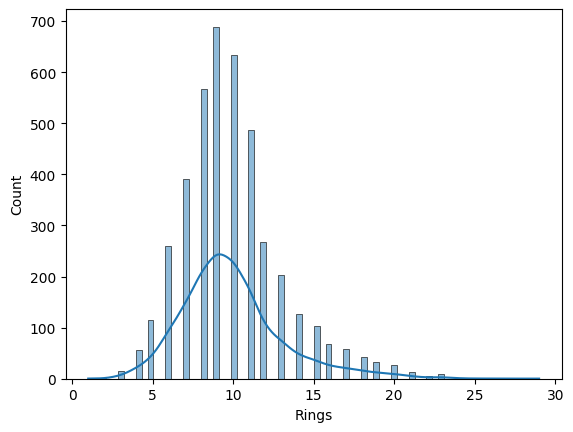

In [ ]:
sns.histplot(data = df['Rings'], kde = True)

Больше всего распределение целевой переменной похоже на нормальное. Начиная с 20 появляется хвост, который может быть трудно прогнозируем моделями так как там мало значений

## 5. Увеличить размер данных простым дублированием до 1_000_000 строк в датасете. Провести сравнение скорости работы Pandas и Polars на увеличенном датасете по параметрам:
## 1.   загрузка данных
## 2.   фильтрация данных
## 3.   агрегация данных



In [ ]:
df_big = df.copy()

for i in range(300):
  df_big = pd.concat([df_big, df])

df_big.to_csv("df_big.csv", index=False)

In [ ]:
df_big.shape, df.shape

((1257277, 9), (4177, 9))

In [ ]:
!pip install polars

import polars as pl

### Загрузка данных

In [ ]:
# Pandas
%%time

df = pd.read_csv("df_big.csv")

CPU times: user 904 ms, sys: 63.7 ms, total: 967 ms
Wall time: 968 ms


In [ ]:
# Polars
%%time

df_pl = pl.read_csv("df_big.csv")

CPU times: user 952 ms, sys: 82.5 ms, total: 1.03 s
Wall time: 563 ms


Вывод: при загрузке данных polars немного быстрее

### Фильтрация данных

In [ ]:
# Pandas
%%time

df.query('Rings > 5')

CPU times: user 65.6 ms, sys: 14.9 ms, total: 80.5 ms
Wall time: 86.2 ms


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.7985,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
1257272,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
1257273,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
1257274,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
1257275,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [ ]:
# Polars
%%time

df_pl.filter(pl.col('Rings') > 5)

CPU times: user 33.3 ms, sys: 61 ms, total: 94.2 ms
Wall time: 98.4 ms


Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
str,f64,f64,f64,f64,f64,f64,f64,i64
"""M""",0.455,0.365,0.095,0.514,0.2245,0.101,0.15,15
"""M""",0.35,0.265,0.09,0.2255,0.0995,0.0485,0.07,7
"""F""",0.53,0.42,0.135,0.677,0.2565,0.1415,0.21,9
"""M""",0.44,0.365,0.125,0.7985,0.2155,0.114,0.155,10
"""I""",0.33,0.255,0.08,0.205,0.0895,0.0395,0.055,7
…,…,…,…,…,…,…,…,…
"""F""",0.565,0.45,0.165,0.887,0.37,0.239,0.249,11
"""M""",0.59,0.44,0.135,0.966,0.439,0.2145,0.2605,10
"""M""",0.6,0.475,0.205,1.176,0.5255,0.2875,0.308,9


Вывод: при фильтрации данных pandas немного быстрее

## Агрегация данных

In [ ]:
# Pandas
%%time

df.groupby('Diameter').agg({'Height' : 'mean', 'Rings' : 'max'})

CPU times: user 62.8 ms, sys: 5.96 ms, total: 68.7 ms
Wall time: 70.1 ms


,Height,Rings
Diameter,,
0.055,0.01000,1
0.090,0.03000,3
0.095,0.03500,4
0.100,0.02750,3
0.105,0.03875,4
...,...,...
0.615,0.20500,12
0.620,0.19500,12
0.625,0.21000,11


In [ ]:
# Polars
%%time

df_pl.group_by('Diameter').agg([
    pl.col('Height').mean(),
    pl.col('Rings').max()
])

CPU times: user 130 ms, sys: 1.38 ms, total: 131 ms
Wall time: 73.5 ms


Diameter,Height,Rings
f64,f64,i64
0.355,0.137794,19
0.21,0.068889,8
0.24,0.081579,9
0.515,0.170522,20
0.41,0.139274,19
…,…,…
0.56,0.190476,18
0.565,0.2075,17
0.22,0.074286,7


Вывод: при агрегации данных pandas немного быстрее